Task1

Training Datasets

In [1]:
import io
import pandas as pd

In [5]:
df_train = pd.read_csv('Fake_train.csv')
print(df_train)

                                                   text     label
0                     നല്ല അവതരണം. സത്യം പുറത്തു വരട്ടെ      Fake
1                                           Masha Allah      Fake
2     അന്വേഷണം കഴിയുമ്പോൾ,. C. A. A. യ്ക്ക് എതിരായ ക...      Fake
3       Illathentha avaru purath vidayittalland verenth      Fake
4     Barana pakshathin matoru niyamam.nalla moyanth...  original
...                                                 ...       ...
3252  വീണാ ജോർജ് എന്ന ഒരു ആരോഗ്യ മന്ത്രി വന്നതിനു ശേ...  original
3253                                 ഇതാണ് പിണുവാതിര😂😂😂  original
3254                                   കേസ് എടുക്കണം 💯👍  original
3255      എല്ലാത്തിനേം 501 സോപ്പിട്ട് കളിപ്പിച്ച് വിടണം  original
3256  Day by day leaders r acting like a fool in dev...  original

[3257 rows x 2 columns]


In [6]:
df_train.label.unique()

array(['Fake', 'original'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# fit_transform was called twice before — the second call re-fit on already-encoded
# integers, producing a no-op but masking the bug. One call is correct.
df_train.label = le.fit_transform(df_train.label)

In [8]:
import re
def preprocess(sentence):
    sentence=str(sentence)
    rem_hashtag=re.sub(r'#\S+', '',sentence)
    rem_tag=re.sub(r'@\S+', '',rem_hashtag)
    rem_punc=re.sub(r'[,|:-<>!@#$%()_-]', '',rem_tag)
    rem_url=re.sub(r'http\S+', '',rem_punc)
    return "".join(rem_url)

In [9]:
df_train['text']=df_train['text'].map(lambda s:preprocess(s))


In [10]:
df_train=df_train.sample(frac=1)
df_train.head(5)

,text,label
2522,1049 ആമത്തേ ഒറ്റപ്പെട്ട സംഭവം . 🙏🏿,1
2696,Kristian Andersen an associate professor of im...,0
2669,chinnayku soprt ula rajayagalil onum ethu vari...,0
1409,10 Varsham munpe Rtpcr Testu Chaithalum 10 Var...,0
159,എല്ലാവരും നിയന്ത്രിച്ചാൽ അവനവന് കൊള്ളം ഇല്ലങ്ക...,1


In [11]:
df_train.label.value_counts()

1    1658
0    1599
Name: label, dtype: int64

In [12]:
!pip install simpletransformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.8/250.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.2/521.2 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 20.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 69.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 11.9 MB/

In [13]:
!pip install transformers==4.24.0
!pip install simpletransformers==0.63.11

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.0
    Uninstalling tokenizers-0.15.0:
      Successfully uninstalled tokenizers-0.15.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.35.2
    Uninstalling transformers-4.35.2:
      Successfully uninstalled transformers-4.35.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
simpletransformers 0.64.3 requires transformers>=4.31.0, but you have transformers 4.24.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.7/250.7 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: simpletransformers
    Found existing installation: simpletransformers 0.64.3
    Uninstalling sim

In [14]:
from simpletransformers.classification import ClassificationModel
from transformers import BertTokenizer

# Load mBERT tokenizer
tokenizer_mbert = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Define the mBERT ClassificationModel
model_mbert = ClassificationModel(
    "bert",
    "bert-base-multilingual-cased",
    num_labels=2,  # Adjust num_labels based on your task
    use_cuda=True,
    args={
        "reprocess_input_data": True,
        "use_cached_eval_features": False,
        "overwrite_output_dir": True,
        "num_train_epochs": 10,  # Adjust the number of training epochs
    }
)


vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [15]:

import pandas as pd
from simpletransformers.classification import ClassificationModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

np.set_printoptions(threshold=np.inf)

In [16]:
model_mbert.train_model(df_train)

/usr/local/lib/python3.10/dist-packages/simpletransformers/classification/classification_model.py:612: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(


  0%|          | 0/3257 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Running Epoch 0 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

Running Epoch 1 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

...

Running Epoch 6 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

Running Epoch 7 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

Running Epoch 8 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

Running Epoch 9 of 10:   0%|          | 0/408 [00:00<?, ?it/s]

(4080, 0.2616704980678418)

Development Datasets

In [17]:
df_test = pd.read_csv('Fake_dev.csv')
print(df_test)

                                                  text     label
0                           Full.  Musilm.   Verodamum      Fake
1    പക്ഷികളും മൃഗങ്ങളും ഈ ലോകത്ത് സുഖമായി ജീവിക്കു...      Fake
2    ഒരു താടിക്കാരൻ പാത്രം കൊട്ടാൻ പറഞ്ഞപ്പോ .........  original
3                                    കുംഭളേമ<br>മറന്നോ  original
4    ഇത് തിരുവാതിര അല്ല...... കോറോണയെ കൈകൊട്ടി കൊല്...  original
..                                                 ...       ...
810             ജനങ്ങൾ വിഡ്ഢികളല്ല .. അത്രേ പറയാനുള്ളു  original
811                                      😂😂ഒരു പിണറായി  original
812  Mr sir are you know about bodhidarma the great...      Fake
813                        ബുദ്ധിയുള്ളവരെ  വിജയിപ്പിക്      Fake
814            വേണ്ടാത്ത പരിപാടിയിപ്പോയി എന്തായാലും...  original

[815 rows x 2 columns]


In [ ]:
# Use transform (not fit_transform) so the dev set uses the same label mapping
# as the training set. fit_transform would refit the encoder on dev labels,
# which can silently reassign class indices.
df_test.label = le.transform(df_test.label)

In [19]:
df_test=df_test.sample(frac=1)
df_test.head(5)

,text,label
178,Ethu anupavekkanathu pavapattavar,0
759,തബ്ലീഗ് സമ്മേളനം കൂടിയദ് ലോക്ക് ഡൗൺ വരുന്നതിന്...,0
470,China kallam parayunnavaranu,0
94,Thabileegenedirey 100 video ittu... Ithiney k...,0
134,എന്നിട്ടും കുറേ എണ്ണം പിന്നാലെ നടക്കുന്നുണ്ടാല്ലോ,1


In [ ]:
# Preprocess BEFORE predicting so the model sees cleaned text, not raw text.
# Previously preprocessing happened two cells after prediction.
df_test['text'] = df_test['text'].map(lambda s: preprocess(s))
predictions, raw_outputs1 = model_mbert.predict(df_test['text'].tolist())

In [22]:

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore',category=FutureWarning)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Preprocessing was moved to the cell above (before prediction).
# This cell is kept as a placeholder so downstream cell numbers stay consistent.

In [24]:
print(classification_report(df_test.label,predictions))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       406
           1       0.85      0.83      0.84       409

    accuracy                           0.84       815
   macro avg       0.84      0.84      0.84       815
weighted avg       0.84      0.84      0.84       815



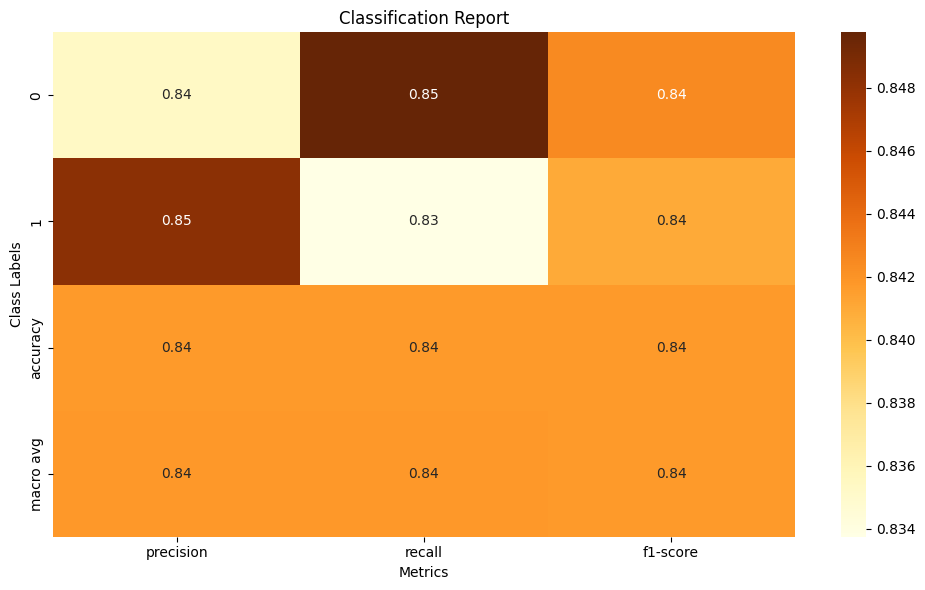

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Assuming you have the true class labels in df_eval.Classlabels and predictions in predictions
report = classification_report(df_test.label, predictions, output_dict=True)

# Convert the report dictionary to a DataFrame for easier visualization
report_df = pd.DataFrame(report).transpose()

# Plot the precision, recall, and F1-score as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlOrBr', fmt='.2f', cbar=True)

# Customize the plot if needed
plt.title('Classification Report')
plt.xlabel('Metrics')
plt.ylabel('Class Labels')
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [27]:
cm = confusion_matrix(df_test.label,predictions)

In [28]:
cm

array([[345,  61],
       [ 68, 341]])

Test Datasets

In [29]:
df_testdata = pd.read_csv('Fake_test_without_labels - Fake_test_without_labels.csv')
print(df_testdata)

                                                   text
0     5000 ഉള്ള പോൾ  ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...
1     ഓഷോ രജനീഷ്  പറഞ്ഞപോലെ  എനിക്കപ്പോൾ തോന്നിയത് അ...
2     ചേട്ടാ  വാർത്ത  വയ്ക്കുന്നത്  കേരളത്തിലാണ്  സം...
3                            Shame for entire Woman&#39
4     135 code janaghal andhu wide business cheythal...
...                                                 ...
1014  Correct ...China cheitha ...weapon spread ing ...
1015  ഈ WHO പറയുന്നതനുസരിച്ചു ചികിത്സയും ലോക്ക് ഡൌൺ ...
1016                                 Mask illa aarkum😏😏
1017   ഇയാളെ  കൊറോണ. രോഗി കൾ കിടയിൽ. ഇടാമായിരുന്നു---!!
1018  Kulathrikalkku badilayiAlavilathikal          ...

[1019 rows x 1 columns]


In [30]:
predictions, raw_outputs1 = model_mbert.predict(df_testdata['text'].tolist())

  0%|          | 0/1019 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

In [31]:
f = open("predictions.txt",'w+')
f.write(str(predictions))

f1 = open("raw_outputs.txt",'w+')
f1.write(str(raw_outputs1))

27513

In [ ]:
# sep='\t' was wrong — the file is comma-separated (consistent with how it was
# read in cell-28). Using the wrong separator caused every row to parse as a
# single field, making the 'labels' column misaligned.
df_tes = pd.read_csv('Fake_test_without_labels - Fake_test_without_labels.csv')
df_tes['labels'] = predictions
df_tes.to_csv('model_mbert.csv')

In [33]:
df_tes1 = pd.read_csv('model_mbert.csv')
#df_tes.to_csv('distil5.tsv', sep='\t',index=False)
df_tes1.head(20)

,Unnamed: 0,text,labels
0,0,5000 ഉള്ള പോൾ ലോഗ്‌ഡ്‌വൻ ഇപ്പോള് 250000 എന്താ...,0
1,1,ഓഷോ രജനീഷ് പറഞ്ഞപോലെ എനിക്കപ്പോൾ തോന്നിയത് അ...,0
2,2,ചേട്ടാ വാർത്ത വയ്ക്കുന്നത് കേരളത്തിലാണ് സം...,1
3,3,Shame for entire Woman&#39,1
4,4,135 code janaghal andhu wide business cheythal...,0
5,5,Why not all countries club together n block ch...,0
6,6,Ethil appuram നാണക്കേഡ് വന്നിട്ടില്ല cpmne🤣🤣🤣a...,1
7,7,കൊറോണ പോയി ഒന്ന് കൂടെ മെച്ചപ്പെട്ട് ഓമൈക്രോനായ...,0
8,8,മോളെ. ഇത് കോമഡി സ്റ്റാർസ് അല്ല. ചിരിച്ചും കളിച...,0
9,9,Marunaadan kandupidutham,0


In [34]:

from google.colab import files
import pandas as pd

# Assuming the code above is already executed to create df_tes and df_tes1

# Save the DataFrame to a CSV file
df_tes.to_csv('model_mbert.csv', index=False)

# Download the CSV file
files.download('model_mbert.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE